In [1]:
from attention_motifs.dataset.dataset import (
	APGenerationConfig,
	PromptDatasetConfig,
	CollectedAttentionPatternDataloader,
)

In [2]:
# magic autoreload
%load_ext autoreload
%autoreload 2

In [11]:
d = CollectedAttentionPatternDataloader.generate(
	config=APGenerationConfig(
		prompts_config=PromptDatasetConfig.from_source_path("../data/pile_100.jsonl"),
		model_names=["pythia-14m"],
	),
)

Processing model: pythia-14m
--------------------------------------------------
| (1.05s) Loading model pythia-14m                                             Loaded pretrained model pythia-14m into HookedTransformer
# (1.11s) Loading model pythia-14m                                             
	loaded pythia-14m with 1179648 parameters
# (0.49s) tokenizing and binning prompts                                       
	shapes of each bin contents (n_seqs, n_ctx): [ (232, 192), (67, 256), (32, 64), (45, 128), (16, 320), (3, 384) ]
getting attention patterns:


n_ctx = 384: 100%|██████████| 395/395 [00:06<00:00, 63.5Seq/s]


In [4]:
import json

print(json.dumps(d.summary(), indent=2))

# for x in d.batches(2):
# 	print(x)

{
  "model_names": [
    "pythia-14m"
  ],
  "dataset_shapes_summary": [
    "(5568, 192, 192)",
    "(1608, 256, 256)",
    "(768, 64, 64)",
    "(1080, 128, 128)",
    "(384, 320, 320)",
    "(72, 384, 384)"
  ],
  "n_datasets": 6,
  "n_total_samples": 9480,
  "n_ctx_stats": {
    "total_items": 9480,
    "n_keys": 6,
    "mode": 192,
    "mean": 191.8379746835443,
    "std": 58.58598852621927,
    "min": 64,
    "q1": 192.0,
    "median": 192.0,
    "q3": 192.0,
    "max": 384
  },
  "config": {
    "__format__": "APGenerationConfig(SerializableDataclass)",
    "prompts_config": {
      "__format__": "PromptDatasetConfig(SerializableDataclass)",
      "name": "pile_100",
      "source_path": "../data/pile_100.jsonl",
      "source_info": {
        "source_path": "../data/pile_100.jsonl"
      },
      "char_len_min": 64,
      "char_len_max": 1024
    },
    "model_names": [
      "pythia-14m"
    ],
    "token_len_min": 64,
    "prompt_token_len_tolerance": 64,
    "raw_scores": fa

In [5]:
d.save("../data/activations/pile_5-tiny-stories-1M", verbose=True)

# (0.02s) Saving metadata                                                      
# (0.08s) Saving prompts                                                       


Saving datasets: 100%|██████████| 6/6 [00:21<00:00,  3.64s/dataset]


In [6]:
d

torch.Size([2, 192, 192])
[AttentionPatternMetadata(model_name='pythia-14m', idx_layer=0, idx_head=0, n_ctx=192, prompt_hash=10697441533221209697), AttentionPatternMetadata(model_name='pythia-14m', idx_layer=0, idx_head=0, n_ctx=192, prompt_hash=8212905469003103652)]


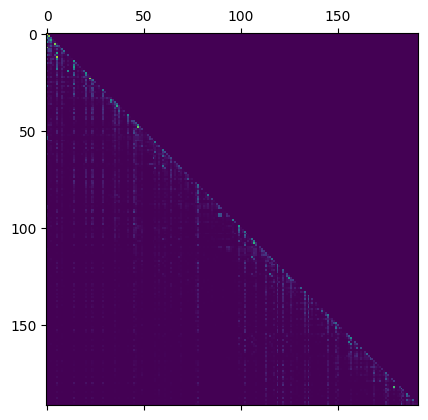

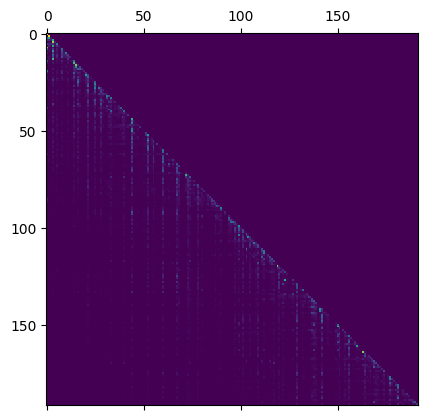

In [7]:
import matplotlib.pyplot as plt

for x in d.batches(2):
	print(x[0].shape)
	print(x[1])
	plt.matshow(x[0][0].cpu().numpy())
	plt.show()
	plt.matshow(x[0][1].cpu().numpy())
	plt.show()
	break